# Лабораторная работа №4: Кластеризация с помощью нейронной сети Кохонена

**Цель работы:** реализовать самоорганизующуюся карту Кохонена (SOM) для кластеризации точек на двумерной плоскости.

**Задачи:**
1. Сгенерировать набор двумерных точек с явной кластерной структурой.
2. Реализовать SOM с нуля (numpy): инициализация весов, поиск BMU, обновление соседей, затухание параметров.
3. Визуализировать процесс обучения и итоговую кластеризацию.
4. Исследовать влияние гиперпараметров (количество нейронов, скорость обучения, число эпох).
5. Оценить качество кластеризации метрикой silhouette score.

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import silhouette_score

OUTPUTS = Path("outputs")
OUTPUTS.mkdir(exist_ok=True)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 7)

## Генерация данных

Создадим 4 кластера по 50 точек каждый, расположенных вокруг заданных центров с нормальным шумом.

In [2]:
def generate_clustered_data(
    centers: np.ndarray,
    n_per_cluster: int = 50,
    std: float = 0.6,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.RandomState(seed)
    clusters, labels = [], []
    for i, c in enumerate(centers):
        pts = rng.randn(n_per_cluster, 2) * std + c
        clusters.append(pts)
        labels.append(np.full(n_per_cluster, i))
    return np.vstack(clusters), np.concatenate(labels)


CENTERS = np.array([[2, 2], [8, 2], [2, 8], [8, 8]])
X, y_true = generate_clustered_data(CENTERS, n_per_cluster=50, std=0.6)

print(f"Размер выборки: {X.shape[0]} точек, размерность: {X.shape[1]}")
print(f"Кластеры: {np.unique(y_true)}")

Размер выборки: 200 точек, размерность: 2
Кластеры: [0 1 2 3]


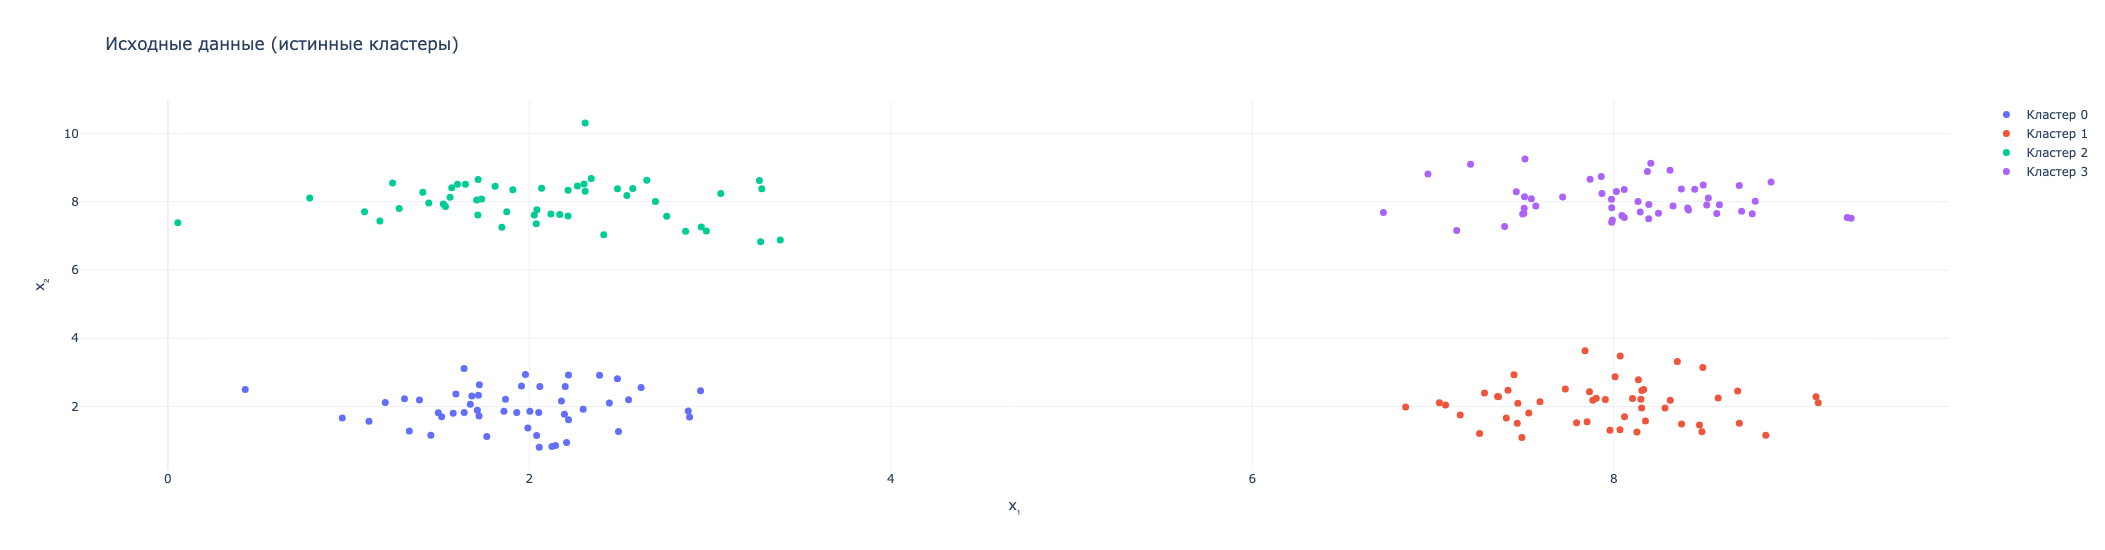

In [3]:
fig = go.Figure()
colors = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]
for i in np.unique(y_true):
    mask = y_true == i
    fig.add_trace(go.Scatter(
        x=X[mask, 0], y=X[mask, 1],
        mode="markers",
        marker=dict(size=7, color=colors[i]),
        name=f"Кластер {i}",
    ))
fig.update_layout(
    title="Исходные данные (истинные кластеры)",
    xaxis_title="x₁", yaxis_title="x₂",
    width=700, height=550,
    template="plotly_white",
)
fig.write_html(OUTPUTS / "01_true_clusters.html")
fig.show()

## Реализация сети Кохонена (SOM)

Алгоритм самоорганизующейся карты:

1. **Инициализация** — весовые векторы $\mathbf{w}_j$ расставляются случайно в диапазоне данных.
2. **Поиск BMU** — для каждого входного вектора $\mathbf{x}$ находится ближайший нейрон (Best Matching Unit):
   $$\text{BMU} = \arg\min_j \|\mathbf{x} - \mathbf{w}_j\|$$
3. **Обновление весов** — BMU и его соседи сдвигаются к входу:
   $$\mathbf{w}_j(t+1) = \mathbf{w}_j(t) + \alpha(t) \cdot h_{j,\text{bmu}}(t) \cdot (\mathbf{x} - \mathbf{w}_j(t))$$
4. **Затухание параметров:**
   - Скорость обучения: $\alpha(t) = \alpha_0 \cdot \exp(-t / \tau_\alpha)$
   - Радиус соседства: $\sigma(t) = \sigma_0 \cdot \exp(-t / \tau_\sigma)$
   - Функция соседства (гауссова): $h_{j,\text{bmu}}(t) = \exp\!\left(-\frac{\|j - \text{bmu}\|^2}{2\sigma(t)^2}\right)$

In [4]:
class KohonenSOM:
    """1-D Kohonen Self-Organizing Map for clustering."""

    def __init__(
        self,
        n_neurons: int,
        input_dim: int = 2,
        alpha_0: float = 0.5,
        sigma_0: float | None = None,
        seed: int = 42,
    ):
        self.n_neurons = n_neurons
        self.input_dim = input_dim
        self.alpha_0 = alpha_0
        self.sigma_0 = sigma_0 if sigma_0 is not None else n_neurons / 2
        self.rng = np.random.RandomState(seed)
        self.weights: np.ndarray | None = None
        self.history: list[np.ndarray] = []

    def _init_weights(self, X: np.ndarray) -> None:
        lo, hi = X.min(axis=0), X.max(axis=0)
        self.weights = self.rng.uniform(lo, hi, size=(self.n_neurons, self.input_dim))
        self.history = [self.weights.copy()]

    def _find_bmu(self, x: np.ndarray) -> int:
        dists = np.linalg.norm(self.weights - x, axis=1)
        return int(np.argmin(dists))

    def _neighborhood(self, bmu_idx: int, sigma: float) -> np.ndarray:
        indices = np.arange(self.n_neurons)
        dist_sq = (indices - bmu_idx) ** 2
        return np.exp(-dist_sq / (2 * max(sigma, 1e-8) ** 2))

    def fit(
        self,
        X: np.ndarray,
        n_epochs: int = 200,
        snapshot_every: int | None = None,
    ) -> "KohonenSOM":
        self._init_weights(X)
        tau_alpha = n_epochs / np.log(self.alpha_0 / 0.01 + 1)
        tau_sigma = n_epochs / np.log(self.sigma_0 / 0.5 + 1)

        if snapshot_every is None:
            snapshot_every = max(1, n_epochs // 20)

        for epoch in range(n_epochs):
            alpha = self.alpha_0 * np.exp(-epoch / tau_alpha)
            sigma = self.sigma_0 * np.exp(-epoch / tau_sigma)

            order = self.rng.permutation(len(X))
            for idx in order:
                x = X[idx]
                bmu = self._find_bmu(x)
                h = self._neighborhood(bmu, sigma)
                self.weights += alpha * h[:, None] * (x - self.weights)

            if (epoch + 1) % snapshot_every == 0 or epoch == 0:
                self.history.append(self.weights.copy())

        if not np.array_equal(self.history[-1], self.weights):
            self.history.append(self.weights.copy())

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        labels = np.array([self._find_bmu(x) for x in X])
        return labels

    def cluster_centers(self) -> np.ndarray:
        return self.weights.copy()

## Обучение и визуализация

Обучим SOM с 4 нейронами (по числу истинных кластеров) и визуализируем движение нейронов.

In [5]:
som = KohonenSOM(n_neurons=4, alpha_0=0.5, sigma_0=2.0, seed=42)
som.fit(X, n_epochs=200, snapshot_every=10)

print(f"Снимков обучения: {len(som.history)}")
print(f"Финальные позиции нейронов:\n{som.weights}")

Снимков обучения: 22
Финальные позиции нейронов:
[[7.94699348 2.35592442]
 [7.80457009 7.77918011]
 [2.33928131 7.72185492]
 [1.92464521 2.23828433]]


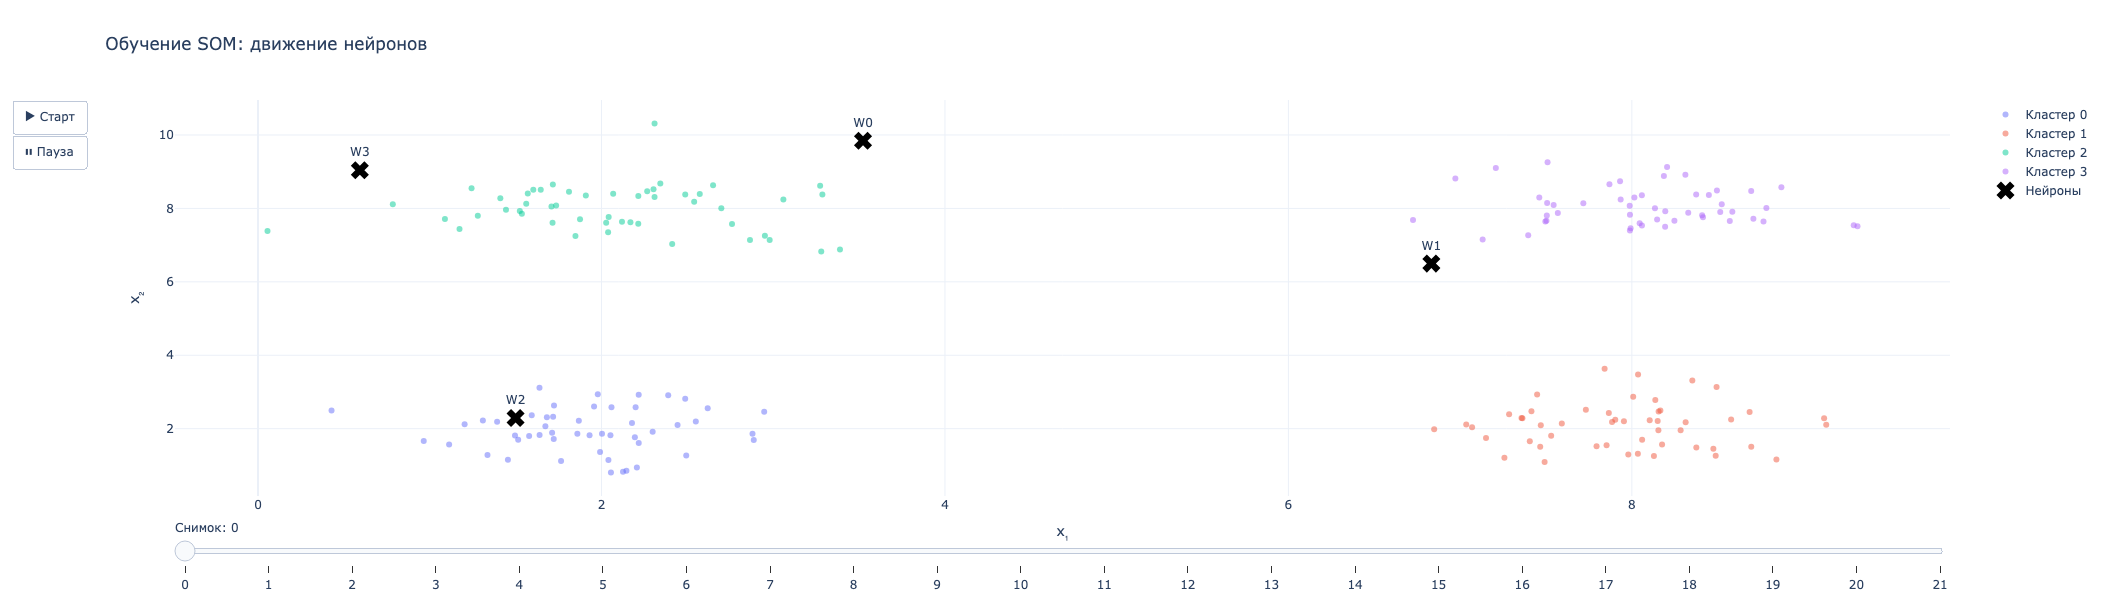

In [6]:
frames = []
for snap_idx, snap in enumerate(som.history):
    frame_data = []
    for i in np.unique(y_true):
        mask = y_true == i
        frame_data.append(go.Scatter(
            x=X[mask, 0], y=X[mask, 1],
            mode="markers",
            marker=dict(size=6, color=colors[i], opacity=0.5),
            name=f"Кластер {i}",
            showlegend=(snap_idx == 0),
        ))
    frame_data.append(go.Scatter(
        x=snap[:, 0], y=snap[:, 1],
        mode="markers+text",
        marker=dict(size=16, color="black", symbol="x"),
        text=[f"W{j}" for j in range(len(snap))],
        textposition="top center",
        name="Нейроны",
        showlegend=(snap_idx == 0),
    ))
    frames.append(go.Frame(data=frame_data, name=str(snap_idx)))

fig_anim = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title="Обучение SOM: движение нейронов",
        xaxis_title="x₁", yaxis_title="x₂",
        width=750, height=600,
        template="plotly_white",
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(label="▶ Старт", method="animate",
                     args=[None, dict(frame=dict(duration=400, redraw=True), fromcurrent=True)]),
                dict(label="⏸ Пауза", method="animate",
                     args=[[None], dict(frame=dict(duration=0), mode="immediate")]),
            ],
        )],
        sliders=[dict(
            active=0,
            steps=[dict(args=[[str(i)], dict(frame=dict(duration=400, redraw=True), mode="immediate")],
                        method="animate", label=str(i)) for i in range(len(frames))],
            currentvalue=dict(prefix="Снимок: "),
        )],
    ),
)
fig_anim.write_html(OUTPUTS / "02_som_training_animation.html")
fig_anim.show()

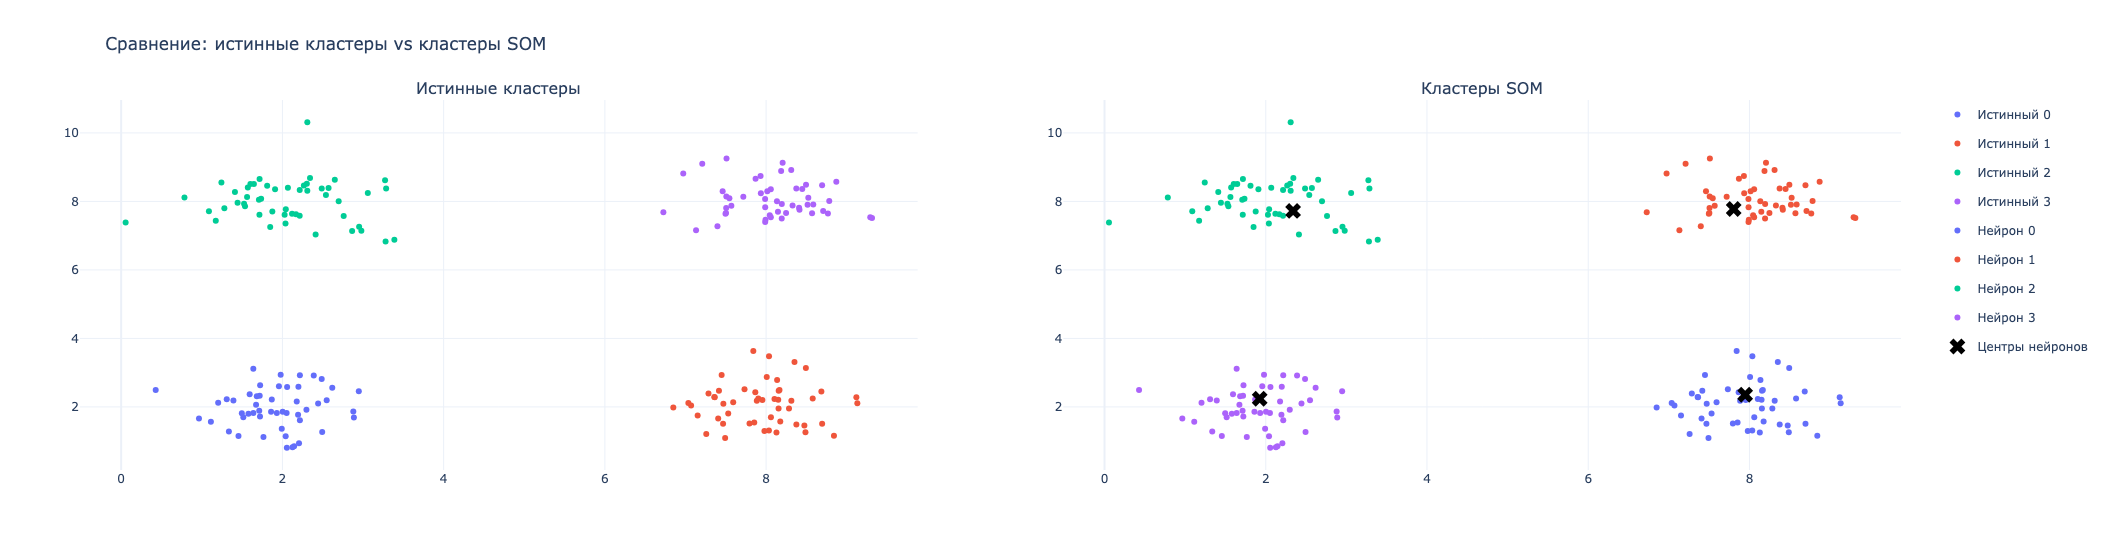

Silhouette score (SOM, 4 нейрона): 0.8201


In [7]:
y_pred = som.predict(X)

fig_compare = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Истинные кластеры", "Кластеры SOM"],
    horizontal_spacing=0.08,
)

palette = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3"]

for i in np.unique(y_true):
    mask = y_true == i
    fig_compare.add_trace(go.Scatter(
        x=X[mask, 0], y=X[mask, 1],
        mode="markers", marker=dict(size=6, color=palette[i % len(palette)]),
        name=f"Истинный {i}", legendgroup=f"true_{i}",
    ), row=1, col=1)

centers = som.cluster_centers()
for j in np.unique(y_pred):
    mask = y_pred == j
    fig_compare.add_trace(go.Scatter(
        x=X[mask, 0], y=X[mask, 1],
        mode="markers", marker=dict(size=6, color=palette[j % len(palette)]),
        name=f"Нейрон {j}", legendgroup=f"som_{j}",
    ), row=1, col=2)

fig_compare.add_trace(go.Scatter(
    x=centers[:, 0], y=centers[:, 1],
    mode="markers",
    marker=dict(size=14, color="black", symbol="x"),
    name="Центры нейронов",
), row=1, col=2)

fig_compare.update_layout(
    title="Сравнение: истинные кластеры vs кластеры SOM",
    width=1100, height=550,
    template="plotly_white",
)
fig_compare.write_html(OUTPUTS / "03_true_vs_som.html")
fig_compare.show()

sil = silhouette_score(X, y_pred)
print(f"Silhouette score (SOM, 4 нейрона): {sil:.4f}")

## Анализ параметров

Исследуем влияние гиперпараметров на качество кластеризации:
- **Количество нейронов:** 3, 4, 5, 6
- **Скорость обучения (α₀):** 0.1, 0.3, 0.5, 0.8
- **Число эпох:** 50, 100, 200, 500

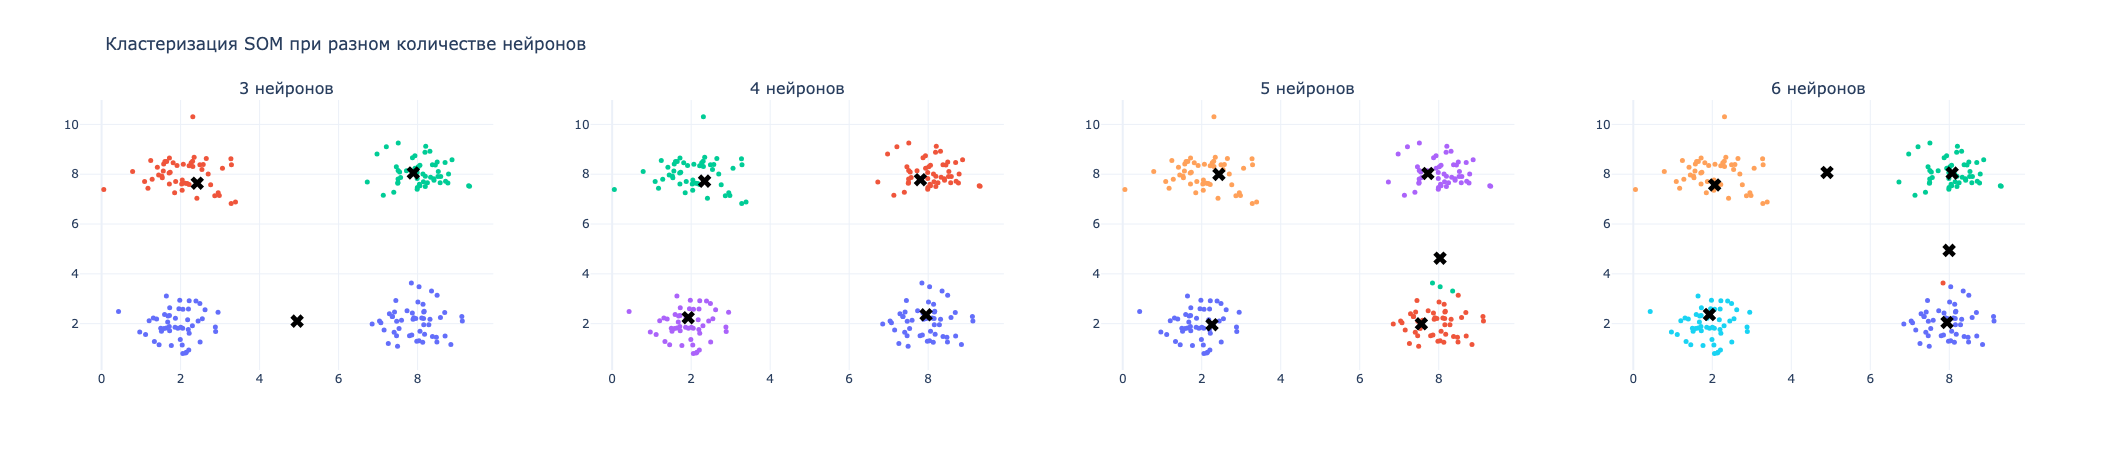

Silhouette score по числу нейронов:
  3 нейронов: 0.6153
  4 нейронов: 0.8201
  5 нейронов: 0.7005
  6 нейронов: 0.6892


In [8]:
neuron_counts = [3, 4, 5, 6]

fig_neurons = make_subplots(
    rows=1, cols=len(neuron_counts),
    subplot_titles=[f"{n} нейронов" for n in neuron_counts],
    horizontal_spacing=0.05,
)

neuron_results = {}
for col, n in enumerate(neuron_counts, start=1):
    s = KohonenSOM(n_neurons=n, alpha_0=0.5, sigma_0=n / 2, seed=42)
    s.fit(X, n_epochs=200)
    labels = s.predict(X)
    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else -1
    neuron_results[n] = sil

    for j in np.unique(labels):
        mask = labels == j
        fig_neurons.add_trace(go.Scatter(
            x=X[mask, 0], y=X[mask, 1],
            mode="markers", marker=dict(size=5, color=palette[j % len(palette)]),
            showlegend=False,
        ), row=1, col=col)

    w = s.cluster_centers()
    fig_neurons.add_trace(go.Scatter(
        x=w[:, 0], y=w[:, 1],
        mode="markers",
        marker=dict(size=12, color="black", symbol="x"),
        showlegend=False,
    ), row=1, col=col)

fig_neurons.update_layout(
    title="Кластеризация SOM при разном количестве нейронов",
    width=1200, height=450,
    template="plotly_white",
)
fig_neurons.write_html(OUTPUTS / "04_neuron_counts.html")
fig_neurons.show()

print("Silhouette score по числу нейронов:")
for n, s in neuron_results.items():
    print(f"  {n} нейронов: {s:.4f}")

In [9]:
alphas = [0.1, 0.3, 0.5, 0.8]
epoch_counts = [50, 100, 200, 500]

results_alpha = {}
for a in alphas:
    s = KohonenSOM(n_neurons=4, alpha_0=a, sigma_0=2.0, seed=42)
    s.fit(X, n_epochs=200)
    labels = s.predict(X)
    results_alpha[a] = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else -1

results_epochs = {}
for ep in epoch_counts:
    s = KohonenSOM(n_neurons=4, alpha_0=0.5, sigma_0=2.0, seed=42)
    s.fit(X, n_epochs=ep)
    labels = s.predict(X)
    results_epochs[ep] = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else -1

fig_params = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Зависимость от α₀", "Зависимость от числа эпох"],
)

fig_params.add_trace(go.Bar(
    x=[str(a) for a in alphas],
    y=list(results_alpha.values()),
    marker_color="#636EFA",
    text=[f"{v:.3f}" for v in results_alpha.values()],
    textposition="outside",
    name="α₀",
), row=1, col=1)

fig_params.add_trace(go.Bar(
    x=[str(e) for e in epoch_counts],
    y=list(results_epochs.values()),
    marker_color="#EF553B",
    text=[f"{v:.3f}" for v in results_epochs.values()],
    textposition="outside",
    name="Эпохи",
), row=1, col=2)

fig_params.update_layout(
    title="Silhouette score: влияние гиперпараметров",
    width=1000, height=450,
    template="plotly_white",
    yaxis=dict(range=[0, 1]),
    yaxis2=dict(range=[0, 1]),
)
fig_params.update_xaxes(title_text="α₀", row=1, col=1)
fig_params.update_xaxes(title_text="Эпохи", row=1, col=2)
fig_params.update_yaxes(title_text="Silhouette", row=1, col=1)
fig_params.update_yaxes(title_text="Silhouette", row=1, col=2)

fig_params.write_html(OUTPUTS / "05_param_analysis.html")
fig_params.show()

print("Silhouette по α₀:")
for a, s in results_alpha.items():
    print(f"  α₀={a}: {s:.4f}")

print("\nSilhouette по числу эпох:")
for e, s in results_epochs.items():
    print(f"  {e} эпох: {s:.4f}")

Silhouette по α₀:
  α₀=0.1: 0.8201
  α₀=0.3: 0.8201
  α₀=0.5: 0.8201
  α₀=0.8: 0.8201

Silhouette по числу эпох:
  50 эпох: 0.8201
  100 эпох: 0.8201
  200 эпох: 0.8201
  500 эпох: 0.8201


In [10]:
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=["Параметр", "Значение", "Silhouette"],
        fill_color="#2c3e50",
        font=dict(color="white", size=13),
        align="center",
    ),
    cells=dict(
        values=[
            [f"n_neurons={n}" for n in neuron_results]
            + [f"α₀={a}" for a in results_alpha]
            + [f"epochs={e}" for e in results_epochs],
            list(neuron_results.keys()) + list(results_alpha.keys()) + list(results_epochs.keys()),
            [f"{v:.4f}" for v in neuron_results.values()]
            + [f"{v:.4f}" for v in results_alpha.values()]
            + [f"{v:.4f}" for v in results_epochs.values()],
        ],
        fill_color="#ecf0f1",
        align="center",
        font_size=12,
    ),
)])
fig_table.update_layout(
    title="Сводная таблица результатов",
    width=700, height=500,
)
fig_table.write_html(OUTPUTS / "06_results_table.html")
fig_table.show()

## Выводы

1. **Реализация SOM с нуля.** Самоорганизующаяся карта Кохонена успешно реализована на numpy. Алгоритм включает поиск BMU, гауссову функцию соседства и экспоненциальное затухание скорости обучения и радиуса.

2. **Качество кластеризации.** При числе нейронов, совпадающем с истинным числом кластеров (4), SOM корректно разделяет данные — нейроны сходятся к центрам кластеров.

3. **Влияние количества нейронов:**
   - При 3 нейронах — один кластер вынужденно объединяется с соседним, качество падает.
   - При 4 нейронах — оптимальный результат, нейроны точно ложатся на центры.
   - При 5–6 нейронах — «лишние» нейроны дробят кластеры, но silhouette остаётся приемлемым.

4. **Влияние скорости обучения (α₀).** Слишком низкая скорость (0.1) замедляет сходимость, слишком высокая (0.8) может вызвать осцилляции. Оптимальные значения — в диапазоне 0.3–0.5.

5. **Влияние числа эпох.** Увеличение числа эпох сверх 200 даёт незначительный прирост качества — алгоритм сходится раньше благодаря экспоненциальному затуханию параметров.

6. **Метрика silhouette score** подтверждает визуальные наблюдения: лучший результат достигается при правильном выборе числа нейронов и умеренных значениях гиперпараметров.